In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import csv
import re

In [125]:
# Read the .csv file
root = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\hparamsearch\\"
path = root + "experiments_golia_20_01.csv"
df = pd.read_csv(path, sep=';')
# # # select the rows from df where the column models has the values ['dcr','mno_reasoner'] 
# models = ['dcr','r2n','gsbr','cdcr','no_reasoner']
# df = df.loc[df['Model_name'].isin(models)]
df.head()

,Task,Grounder,KGE,EmbedSize,WeightLoss_Task,Reasoner_depth,Model_name,Time,train_loss,train_concept_loss,...,val_task_hits@3@3,test_loss,test_concept_loss,test_task_loss,test_concept_mrr,test_concept_hits@1@1,test_concept_hits@3@3,test_task_mrr,test_task_hits@1@1,"test_task_hits@3@3,,,,,,,,,,,,,,,,,,,,,,,,,,,,"
0,nations_AMIE,backward_1,complex,100,0.5,1,rnm,"[81.11701183319092, 0.9713907642988604]","[0.0132, 0.0001]","[0.0132, 0.0001]",...,"[0.0, 0.0]","[0.381, 0.0086]","[0.381, 0.0086]","[0.381, 0.0086]","[0.6993, 0.003]","[0.596, 0.0043]","[0.7323, 0.0043]","[0.6993, 0.003]","[0.596, 0.0043]","[0.7323, 0.0043]"
1,nations_AMIE,backward_1,complex,100,0.5,1,dcr,"[166.7095664024353, 1.6524769655731903]","[0.1728, 0.0006]","[0.0168, 0.0004]",...,"[0.0, 0.0]","[0.5019, 0.0075]","[0.3688, 0.0073]","[0.3544, 0.0078]","[0.7058, 0.0032]","[0.6015, 0.0069]","[0.7448, 0.0046]","[0.7096, 0.0064]","[0.607, 0.008]","[0.7428, 0.0062]"
2,nations_AMIE,backward_1,complex,100,0.5,1,r2n,"[107.00683574676513, 4.064499004229695]","[0.016, 0.0005]","[0.017, 0.0007]",...,"[0.0, 0.0]","[0.3542, 0.007]","[0.3601, 0.006]","[0.3483, 0.0081]","[0.7039, 0.0065]","[0.6015, 0.0102]","[0.7443, 0.0084]","[0.7058, 0.0068]","[0.604, 0.0115]","[0.7428, 0.0094]"
3,nations_AMIE,backward_1,complex,100,0.5,1,sbr,"[82.9300012588501, 2.115171744003833]","[0.0132, 0.0001]","[0.0132, 0.0001]",...,"[0.0, 0.0]","[0.381, 0.0086]","[0.381, 0.0086]","[0.381, 0.0086]","[0.6993, 0.003]","[0.596, 0.0043]","[0.7323, 0.0043]","[0.6993, 0.003]","[0.596, 0.0043]","[0.7323, 0.0043]"
4,nations_AMIE,backward_1,complex,100,0.5,1,gsbr,"[94.95517454147338, 1.906723073578068]","[0.0134, 0.0001]","[0.0135, 0.0001]",...,"[0.0, 0.0]","[0.379, 0.0084]","[0.3797, 0.0083]","[0.3784, 0.0085]","[0.6996, 0.0045]","[0.5965, 0.0051]","[0.7338, 0.0065]","[0.7008, 0.0049]","[0.5985, 0.0062]","[0.7333, 0.0064]"


In [126]:
# remove the duplicates in df
df = df.drop_duplicates()

In [127]:
for column in df:
    try:
        # For all the colum, apply eval() to convert the string to a list
        if column != 'KGE':
            df[column] = [np.array(eval(i)) for i in df[column].values]
    except:
        print("Error in ", column)
        continue

# for each col that is a string or int or object, print the unique values 
for col in df.columns:
    try: 
        if df[col].dtype == 'object' or df[col].dtype == 'int64' or df[col].dtype == 'string':
            print(col)
            print(df[col].unique())
            print()
    except:
        continue

# results = df.loc[(df['Grounder'] == 'known') & (df['KGE'] == 'distmult') & (df['EmbedSize'] == 10)]

Error in  Task
Error in  Grounder
Error in  EmbedSize
Error in  WeightLoss_Task
Error in  Reasoner_depth
Error in  Model_name
Task
['nations_AMIE' 'nations_NCRL' 'countries_s1' 'countries_s2'
 'countries_s3' 'kinship_family' 'pharmkg_supersmall']

Grounder
['backward_1' 'known' 'backward_2' 'backward_3' 'full' 'domainbody']

KGE
['complex']

EmbedSize
[100]

Reasoner_depth
[1]

Model_name
['rnm' 'dcr' 'r2n' 'sbr' 'gsbr' 'cdcr' 'no_reasoner']

Time
train_loss
train_concept_loss
train_task_loss
train_concept_mrr
train_concept_hits@1@1
train_concept_hits@3@3
train_task_mrr
train_task_hits@1@1
train_task_hits@3@3
val_loss
val_concept_loss
val_task_loss
val_concept_mrr
val_concept_hits@1@1
val_concept_hits@3@3
val_task_mrr
val_task_hits@1@1
val_task_hits@3@3
test_loss
test_concept_loss
test_task_loss
test_concept_mrr
test_concept_hits@1@1
test_concept_hits@3@3
test_task_mrr
test_task_hits@1@1
test_task_hits@3@3,,,,,,,,,,,,,,,,,,,,,,,,,,,,


In [130]:
def split_df(df):
    # create a df that is the same as the original but with the first value of the colums in the list metrics
    df_mean = df.copy()
    for col in df_mean.columns:
        try:
            df_mean[col] = [i[0] for i in df_mean[col].values]
        except:
            continue
    # Do the same for the std
    df_std = df.copy()
    for col in df_std.columns:
        try:
            df_std[col] = [i[1] for i in df_std[col].values]
        except:
            continue
    return df_mean, df_std

In [131]:
cols = 'Grounder'
rows = 'Model_name'
metrics = ['test_task_mrr', 'Time']
KGEs = ['complex'] #, 'distmult', 'transe']
baseline_model = 'no_reasoner'
baseline_metric = 'test_concept_mrr'
tasks = ['countries_s1','countries_s2', 'countries_s3', 'nations_NCRL', 'nations_AMIE','kinship_family','pharmkg_supersmall']
models = ['dcr','r2n','gsbr','cdcr','no_reasoner']

In [132]:
# select the rows from df where the column models has the values ['dcr','mno_reasoner'] 
models = ['dcr','r2n','gsbr','cdcr','no_reasoner']
df = df.loc[df['Model_name'].isin(models)]

# Tables

One table for the different models with KGE complex (also for the other KGEs)
Another table for the different KGEs
Another table for the time with the best model and the best KGE

In [133]:
# Table 1: rows:grounder, cols:Model, values: mrr
csv_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\hparamsearch\\results.csv"
for task in tasks:
    for metric in metrics:
        for KGE in ['complex']: #, 'distmult', 'transe']:
            print('KGE: ', KGE, ' Metric: ', metric, ' Task: ', task)
            # filter the df
            results = df.loc[ (df['Task'] == task) &(df['KGE'] == KGE) ].copy() #& (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
            # take only the columns grounder, model, test_task_mrr, test_concept_mrr
            results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
            # results = results.drop_duplicates( keep='first')
            print(results)
            # put the model_name as colums
            results = results.pivot(index=rows, columns=cols, values=metric)
            if metric == 'test_task_mrr':
                # in the column no_reasoner, put the values of the column test_concept_mrr
                substitute = df.loc[(df['Task'] == task) & (df['KGE'] == KGE) & (df['Model_name'] == baseline_model) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)][[cols,rows,baseline_metric]]
                substitute = substitute.pivot(index=rows, columns=cols, values=baseline_metric)
                # substitute the values in the table
                results.loc[baseline_model] = substitute.loc[baseline_model] 

            # with open(csv_dir, 'a') as f:
            #     f.write('\n Task : ,' + task + 'KGE : ,' + KGE + ', Metric: ,' + metric)
            #     f.write('\n ') 
            # results.to_csv(csv_dir, mode='a', header=True)  
results

KGE:  complex  Metric:  test_task_mrr  Task:  countries_s1
      Grounder   Model_name     test_task_mrr
57  backward_1          dcr  [0.9437, 0.0347]
58  backward_1          r2n  [0.9839, 0.0274]
60  backward_1         gsbr  [0.9313, 0.0292]
61  backward_1         cdcr  [0.9317, 0.0231]
62  backward_1  no_reasoner  [0.7234, 0.0209]
64       known          dcr  [0.9437, 0.0347]
65       known          r2n  [0.9839, 0.0274]
67       known         gsbr  [0.9313, 0.0292]
68       known         cdcr  [0.9317, 0.0231]
69       known  no_reasoner  [0.7234, 0.0209]
71  backward_2          dcr    [0.9238, 0.02]
72  backward_2          r2n  [0.9242, 0.0198]
74  backward_2         gsbr    [0.9238, 0.02]
75  backward_2         cdcr    [0.9238, 0.02]
76  backward_2  no_reasoner  [0.7234, 0.0209]
78  backward_3          dcr    [0.9238, 0.02]
79  backward_3          r2n  [0.9242, 0.0198]
81  backward_3         gsbr    [0.9238, 0.02]
82  backward_3         cdcr    [0.9238, 0.02]
83  backward_3  no_re

Grounder,backward_1,backward_2,backward_3,domainbody,full,known
Model_name,,,,,,
cdcr,"[292.6767447948456, 5.135831095435754]","[336.4075647354126, 18.763050004436284]","[325.93116788864137, 7.626744750547473]","[340.4586035251617, 4.972890089000081]","[708.2791563034058, 11.39016656827336]","[330.8979754447937, 11.632837573054905]"
dcr,"[208.37259182929992, 2.7886823904444635]","[241.50284304618836, 15.919109029917117]","[241.60798425674437, 20.236392232761677]","[238.79807505607604, 6.880930790854147]","[368.42602639198304, 5.333249118761606]","[240.64396719932557, 5.024759669850119]"
gsbr,"[80.2020495891571, 2.6547761693706917]","[92.77196507453918, 19.895603322550322]","[87.9776963710785, 20.22840386527597]","[93.77053174972534, 2.9524102836130868]","[138.98086767196656, 11.297521187917797]","[84.80177540779114, 11.414383428717052]"
no_reasoner,"[30.824060583114623, 8.628661494313198]","[37.91823239326477, 22.098013505683717]","[31.171931266784668, 5.9850033464324]","[31.6405291557312, 9.974902313587402]","[26.23549928665161, 0.4707576450555459]","[34.55238747596741, 15.569405080002232]"
r2n,"[100.21234698295594, 3.5581917913756964]","[107.9355489730835, 21.15435859557903]","[105.44233593940734, 23.213818004298457]","[115.9834746837616, 2.435616870252176]","[318.9719336986542, 10.62817616666418]","[104.66761527061462, 10.941081295439895]"


In [134]:
# # Table 1: rows:grounder, cols:Model, values: mrr
# csv_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\code\\keras-ns\\experiments\\countries\\hparamsearch\\results.csv"
# cols = 'Grounder'
# rows = 'KGE'
# metrics = ['test_task_mrr','Time']
# for metric in metrics:
#     for model in df['Model_name'].unique():
#         # filter the df
#         results = df.loc[ (df['Model_name'] == model) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
#         # take only the columns grounder, model, test_task_mrr, test_concept_mrr
#         results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
#         # put the model_name as colums
#         results = results.pivot(index=rows, columns=cols, values=metric)
#         # print(results)
#         # with open(csv_dir, 'a') as f:
#         #     f.write('\nModel : ,' + model + ', Metric: ,' + metric)
#         #     f.write('\n ')
#         # results.to_csv(csv_dir, mode='a', header=True)  
# results

# PLOTS

In [135]:
step = 'test'
metric = step+'_task_mrr'
baseline_metric = step+'_concept_mrr'
metrics = [step+'_task_mrr','Time']
metric_names = {step+'_task_mrr':'MRR', 'Time':'Time (s)'}

KGE:  complex  Metric:  test_task_mrr  Task:  countries_s1


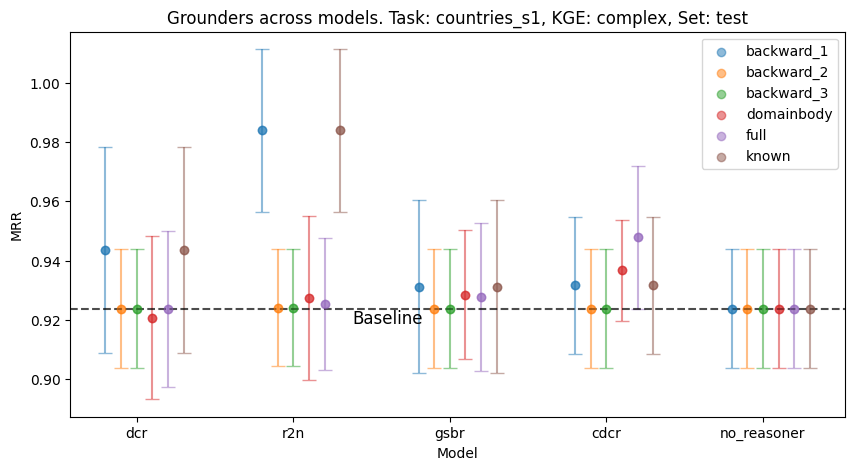

KGE:  complex  Metric:  Time  Task:  countries_s1


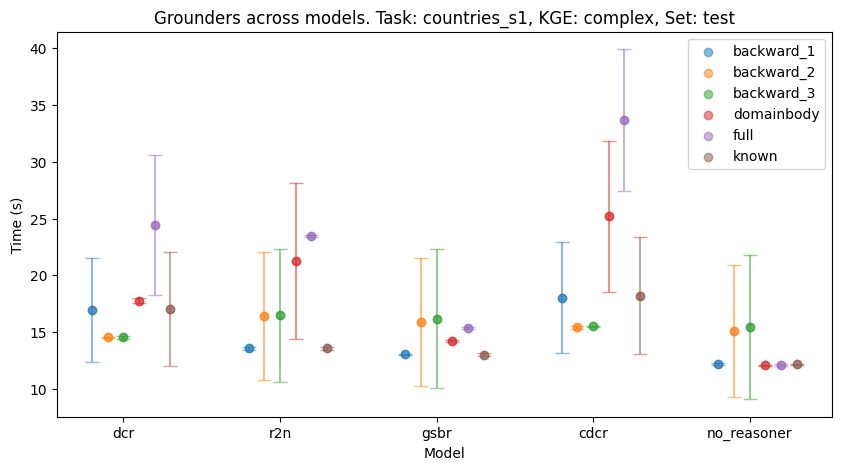

KGE:  complex  Metric:  test_task_mrr  Task:  countries_s2


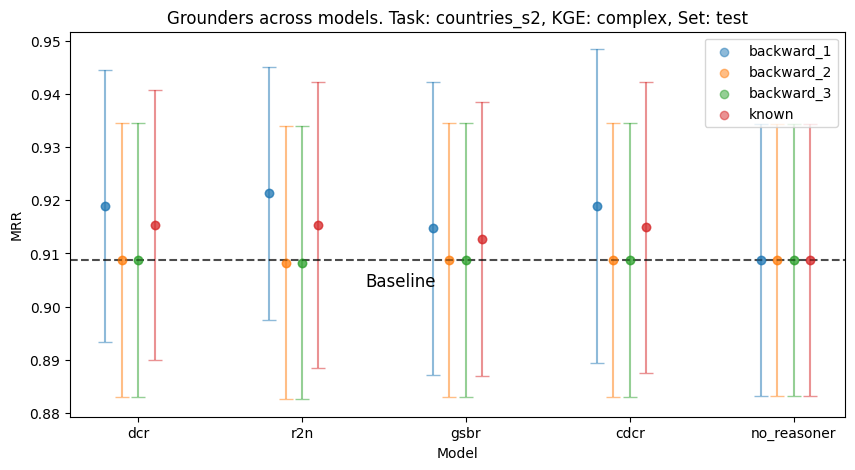

KGE:  complex  Metric:  Time  Task:  countries_s2


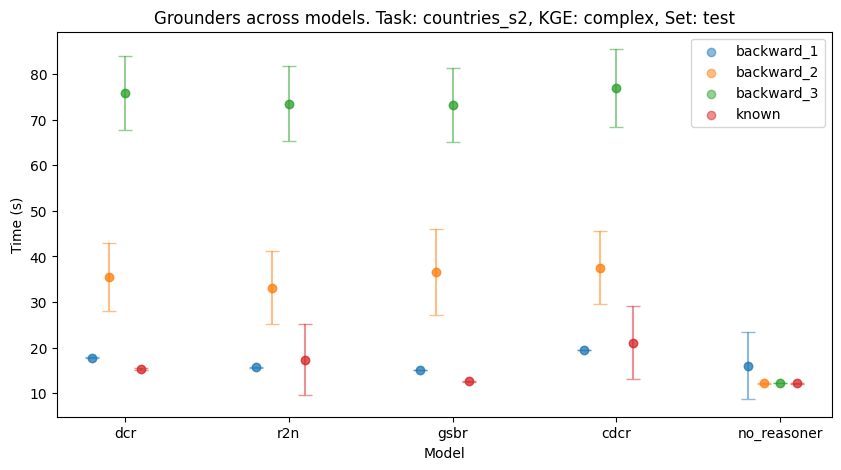

KGE:  complex  Metric:  test_task_mrr  Task:  countries_s3


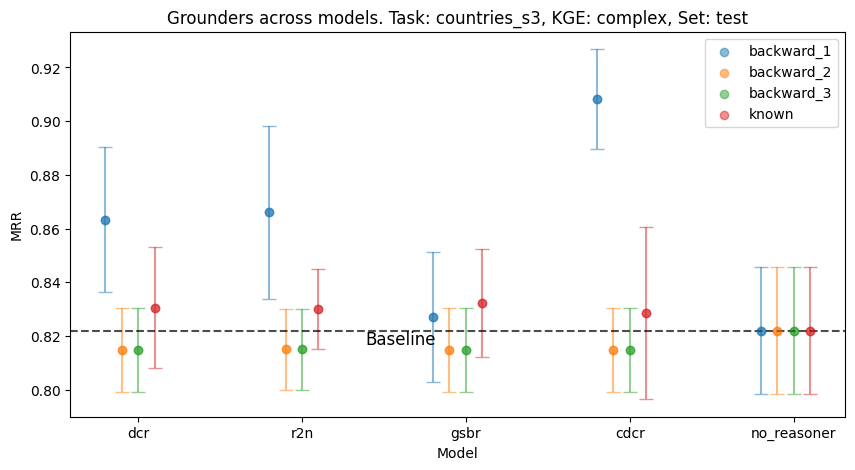

KGE:  complex  Metric:  Time  Task:  countries_s3


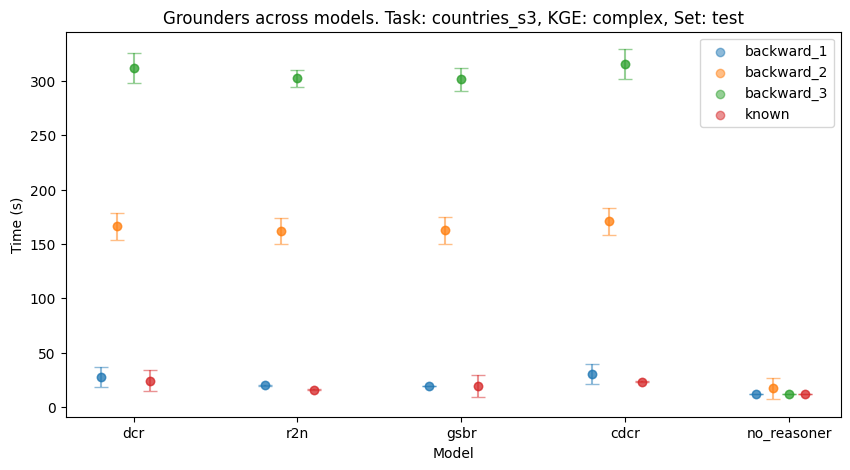

KGE:  complex  Metric:  test_task_mrr  Task:  nations_NCRL


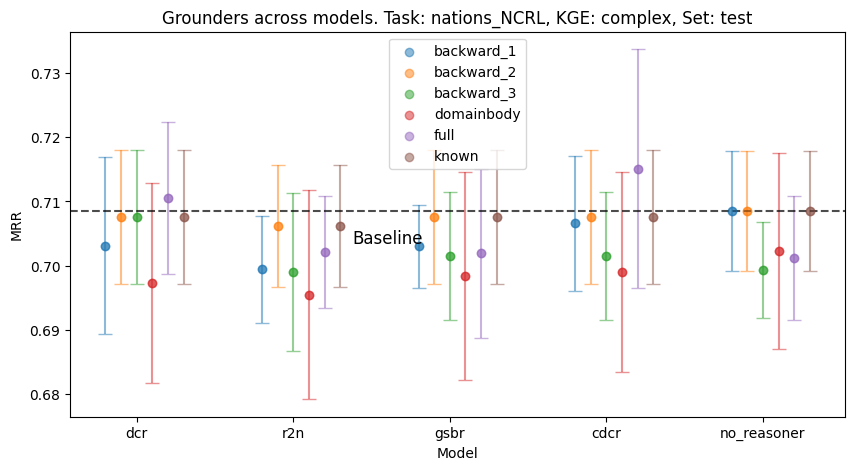

KGE:  complex  Metric:  Time  Task:  nations_NCRL


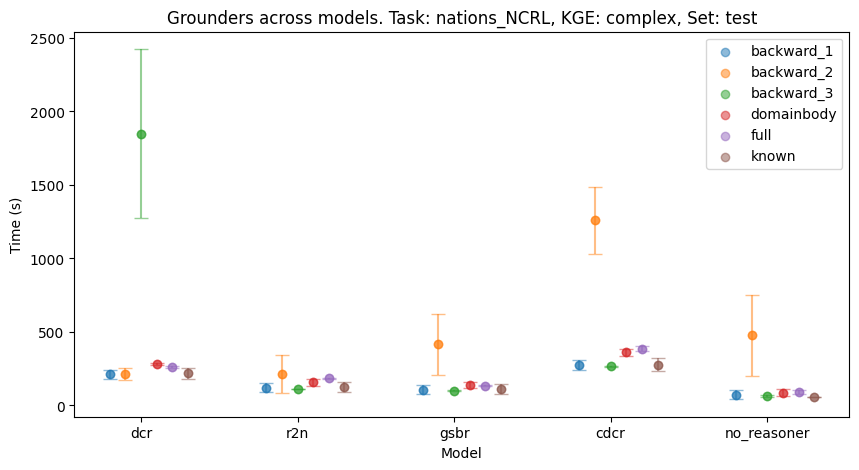

KGE:  complex  Metric:  test_task_mrr  Task:  nations_AMIE


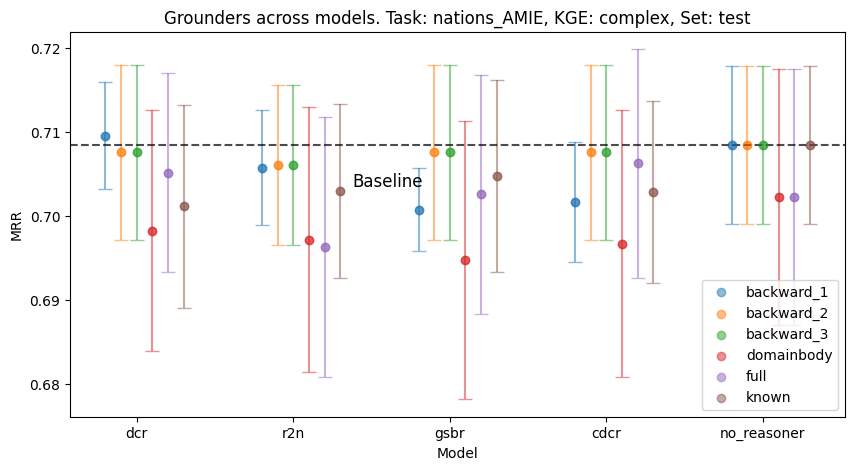

KGE:  complex  Metric:  Time  Task:  nations_AMIE


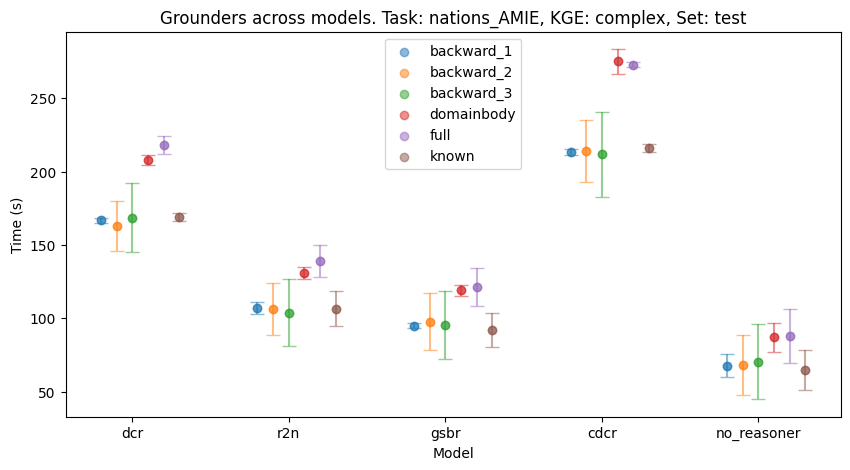

KGE:  complex  Metric:  test_task_mrr  Task:  kinship_family


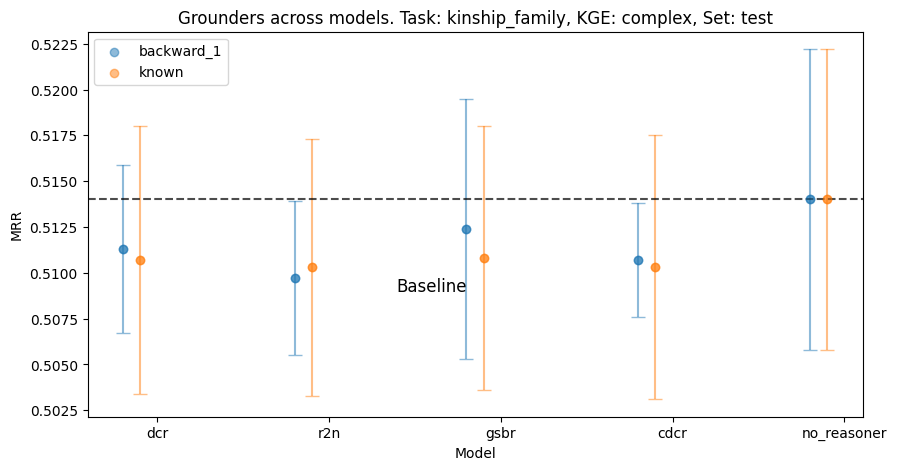

KGE:  complex  Metric:  Time  Task:  kinship_family


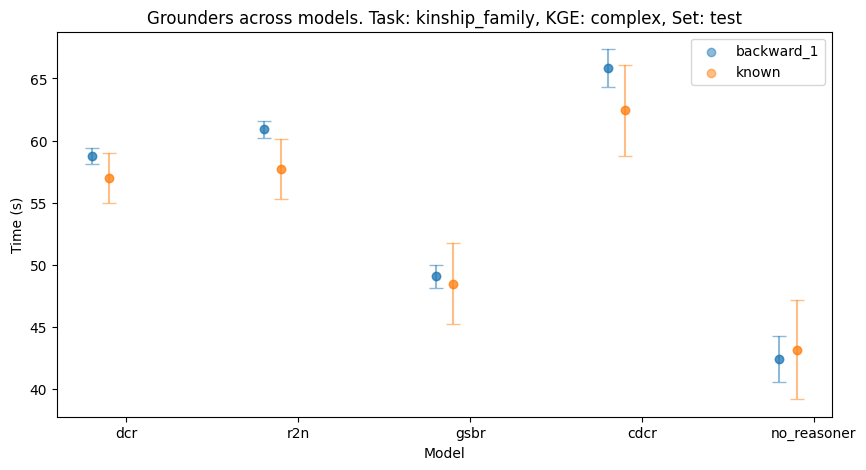

KGE:  complex  Metric:  test_task_mrr  Task:  pharmkg_supersmall


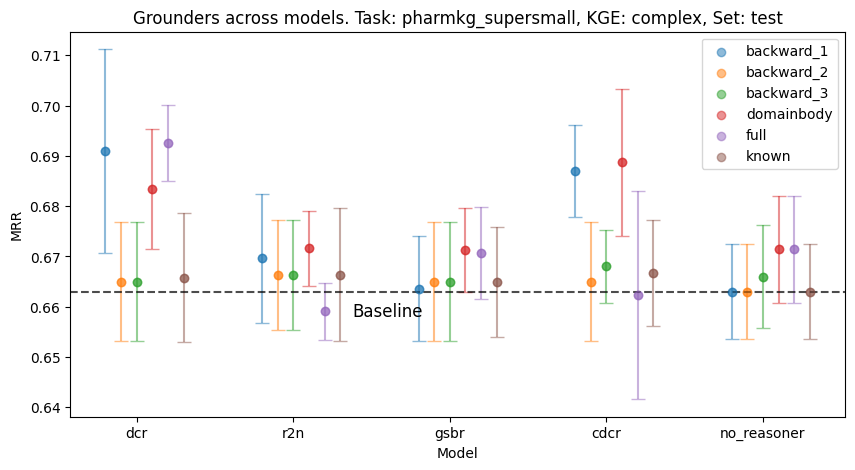

KGE:  complex  Metric:  Time  Task:  pharmkg_supersmall


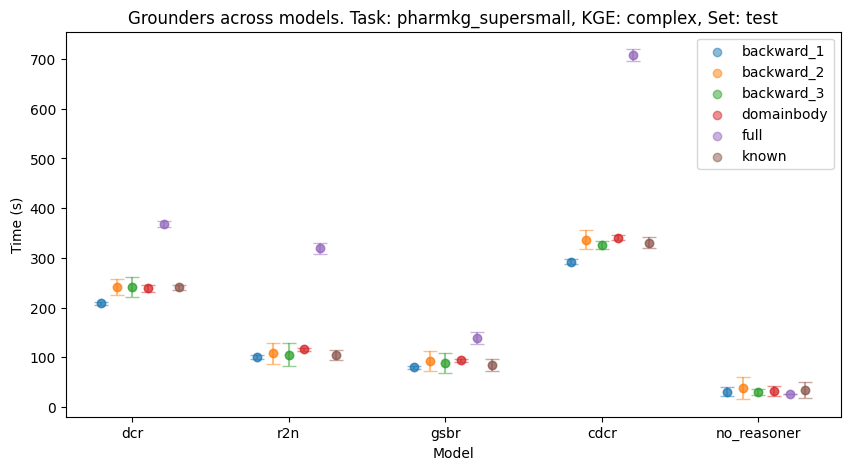

In [136]:
# Table 1: rows:grounder, cols:Model, values: mrr
root_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\hparamsearch\\"
for task in tasks:
    for metric in metrics:
        for KGE in KGEs:
            print('KGE: ', KGE, ' Metric: ', metric, ' Task: ', task)
            # filter the df
            results = df.loc[(df['Task'] == task) & (df['KGE'] == KGE) ].copy() #& (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
            # take only the columns grounder, model, test_task_mrr, test_concept_mrr
            results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
            # put the model_name as colums
            results = results.pivot(index=rows, columns=cols, values=metric)

            if metric == step+'_task_mrr':
                # in the column no_reasoner, put the values of the columnstep+ _concept_mrr
                substitute = df.loc[(df['Task'] == task) & (df['KGE'] == KGE) & (df['Model_name'] == baseline_model) ][[cols,rows,baseline_metric]] # & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)][[cols,rows,baseline_metric]]
                substitute = substitute.pivot(index=rows, columns=cols, values=baseline_metric)
                # substitute the values in the table
                results.loc[baseline_model] = substitute.loc[baseline_model]
            df_mean, df_std = split_df(results)
            # print(df_mean)
            # Remove no reasoner and include a line where it is written baseline
            plt.figure(figsize=(10,5))
            for i,grounder in enumerate(df_mean.columns):
                plt.scatter(np.arange(len(df_mean.loc[models].index))+0.1*i, df_mean.loc[models][grounder], label=grounder, alpha=0.5)
                plt.errorbar(np.arange(len(df_mean.loc[models].index))+0.1*i, df_mean.loc[models][grounder], yerr=df_std.loc[models][grounder], fmt='o',capsize=5, alpha=0.5)
            if metric == step+'_task_mrr':
                plt.axhline(y=df_mean.loc[baseline_model].values[0], color='black', linestyle='--', alpha=.7)  # Change color and linestyle as desired
                plt.text(1.8, df_mean.loc[baseline_model].values[0]-0.005, 'Baseline', color='black', fontsize=12, ha='center')
                # print(df_mean.loc[baseline_model].values[0])
            plt.legend()
            plt.xticks(np.arange(len(df_mean.loc[models].index))+0.2, df_mean.loc[models].index.tolist(), rotation=0)
            plt.ylabel(metric_names[metric])
            plt.xlabel('Model')
            plt.title(f'Grounders across models. Task: {task}, KGE: {KGE}, Set: {step}')
            plt.show()
            # SAVE THE FIGURE
            # plt.savefig(root_dir+'figures\\Grounders_across_models__'+'Task_'+task+'_Metric_'+metric+'_KGE_'+KGE+'.png', dpi=300, bbox_inches='tight')  

In [10]:
# cols = 'Grounder'
# rows = 'KGE'
# metric = 'test_task_mrr'
# baseline_model = 'no_reasoner'
# baseline_metric = 'test_concept_mrr'
# for metric in ['test_task_mrr', 'Time']:
#     for model in df['Model_name'].unique():
#         if model !='no_reasoner':
#             # filter the df
#             results = df.loc[ (df['Model_name'] == model) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
#             # take only the columns grounder, model, test_task_mrr, test_concept_mrr
#             results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
#             # put the model_name as colums
#             results = results.pivot(index=rows, columns=cols, values=metric)

#             df_mean, df_std = split_df(results)
#             # Remove no reasoner and include a line where it is written baseline
#             plt.figure(figsize=(10,5))
#             for i,grounder in enumerate(df_mean.columns):
#                 plt.scatter(np.arange(len(df_mean.index))+0.1*i, df_mean[grounder], label=grounder, alpha=0.5)
#                 plt.errorbar(np.arange(len(df_mean.index))+0.1*i, df_mean[grounder], yerr=df_std[grounder], fmt='o',capsize=5, alpha=0.5)
#             plt.legend()
#             plt.xticks(np.arange(len(df_mean.index))+0.1*i, df_mean.index.tolist(), rotation=0)
#             plt.ylabel('MRR test')
#             plt.xlabel('KGE')
#             plt.title(f'Grounders across KGEs for model {model}')
#             plt.show()
#             # plt.savefig(root_dir+'figures\\Grounders_across_KGE___Model_'+model+'.png', dpi=300, bbox_inches='tight')  